# The Metal Corpus
### A Linguistic Analysis of Metal Lyrics

*A data science portfolio project by William Anderson*

---

## Setup & Context

This notebook analyzes a SQLite database built from lyrics collected across 1,109 artists, 8,277 releases,  and 63,216 songs, for a total of 16.4 million words and 127,532 unique terms. Releases are categorized into 13 subgenres: heavy, thrash, death, black, doom, progressive, power, groove, glam, nu, alternative, gothic metal, and metalcore. These categories are broader than the genre tags used by Discogs; for example, symphonic metal and power metal are both grouped under 'power', and funk metal falls under another category, 'other'. Where this categorization affects a finding, it's explicitly noted.

Data was collected via the Genius, Discogs, and MusicBrainz APIs and processed through a four-script pipeline. For the full technical breakdown, see the [README](../README.md).

To start, import the necessary libraries and connect to the database.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect('metal_lyrics109.db')

subgenres = ['heavy', 'thrash', 'death', 'black', 'groove', 'progressive', 'doom', 'power', 'glam', 'nu', 'metalcore', 'alt', 'gothic', 'other']

df_words = pd.read_sql("SELECT * FROM words", conn)
df_artists = pd.read_sql("SELECT * FROM artists", conn) # results 1,296 artists. Some of them, I'm keeping in the artists table 
                                                        # along with their information (vocalist_gender and country), but either 
                                                        # Discogs or Genius returned empty, so they have no lyrics included in this project
df_active_artists = pd.read_sql("""
    SELECT COUNT(DISTINCT artist_id) as active_artists
    FROM releases
""", conn)
df_releases = pd.read_sql("SELECT * FROM releases", conn)
df_songs = pd.read_sql("SELECT * FROM songs", conn)

print(f"Total words in corpus: {df_words[subgenres].sum().sum():,}")
print(f"Unique words: {len(df_words):,}")
print(f"Artists: {df_active_artists['active_artists'][0]:,}")
print(f"Releases: {len(df_releases):,}")
print(f"Songs: {len(df_songs):,}")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/williamanderson/VisualStudio/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 651, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/williamanderson/VisualStudio/.venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/williamanderson/VisualStudio/.venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/Users/williamanderson/VisualStudio/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 706, in __get__
    return self.get(obj, cls)  # type:ignore[return-value]
  File "/Users/williamanderson/VisualStudio/.venv/lib/python3.9/site-packages/traitlets/traitlets.py", line 668,

Total words in corpus: 16,652,348
Unique words: 127,221
Artists: 1,113
Releases: 8,346
Songs: 63,647


---

## Dataset Overview

### Methodology & Data Collection

*A brief overview of how this dataset was built. For a deeper discussion of limitations and edge cases, see the [Methodology & Limitations](#methodology--limitations) section later in this notebook.*

1. How bands were selected
   - Started with well-known bands and commonly cited founders of each subgenre. Expanded to include lesser-known and more recent bands.
   - Deliberate effort to include female-fronted bands and geographic diversity
   - Bands sourced from personal knowledge, community reccomendations, and online rabbit holes
2. How discographies were built
   - Discogs API for tracklists and release metadata
   - MusicBrainz API for release type (Album, EP, etc.)
   - Manual review in Excel before lyrics are fetched
3. How lyrics were collected
   - Genius API for raw lyrics
   - Fallback logic for songs not found under their original title
   - Artist verification to reject wrong artist fetches
   - Demos, live versions, alternate versions, etc. are filtered automatically
4. Known limitations
   - English-language bias: Non-English lyrics just appear as noise, especially in black metal
   - Single-band skew: A single band focused on one subject may affect their subgenre's word usage (Alestorm: 'pirates' and 'rum'; Limp Bizkit: 'Limp' and 'Bizkit')
   - Cover songs are not removed and are treated as separate data points
   - Song, release, and artist names with special characters are occasionally lost in the pipeline
   - Subgenre classification is purposefully kept broad and limited to 14
   - Selection bias to well-known bands and albums. Underground and obscure releases are under-represented.
   - Proper nouns are not filtered. This is a known limitation that would likely require Named Entity Recognition (NER) to address.

---

### Word Count by Subgenre

Raw word counts reflect both the verbosity of a genre *and* how many bands are represented in the dataset. Heavy and death metal have the most data simply because more bands exist in those categories. The analyses that follow normalize for this where appropriate.

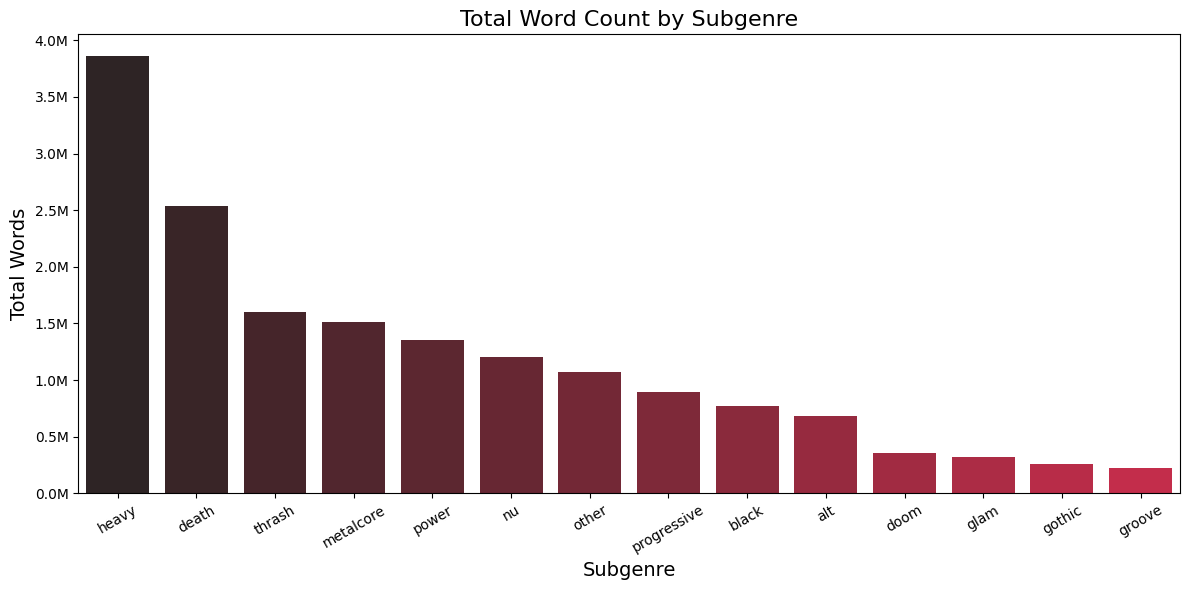

   subgenre  total_words percent_of_total
      heavy      3859933              23%
      death      2540850              15%
     thrash      1605285              10%
  metalcore      1511572               9%
      power      1355507               8%
         nu      1202608               7%
      other      1074455               6%
progressive       898786               5%
      black       767756               5%
        alt       678101               4%
       doom       359905               2%
       glam       318760               2%
     gothic       259562               2%
     groove       219268               1%


In [2]:
# Word count by subgenre

df_words = pd.read_sql("SELECT * FROM words", conn)

totals = {s: df_words[s].sum() for s in subgenres}
totals_df = pd.DataFrame(list(totals.items()), columns=['subgenre', 'total_words'])
totals_df = totals_df.sort_values('total_words', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=totals_df, x='subgenre', y='total_words', hue='subgenre', palette='dark:crimson', legend=False)
plt.title('Total Word Count by Subgenre', fontsize=16)
plt.xlabel('Subgenre', fontsize=14)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.ylabel('Total Words', fontsize=14)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

totals_df['percent_of_total'] = (totals_df['total_words'] / totals_df['total_words'].sum() * 100).round(0).astype(int).astype(str) + '%'
print(totals_df.to_string(index=False))

---

###  Country Representation

This dataset includes lyrics of bands from 45 countries. The United States leads by a significant margin, showing both the country's outsized influence on metal's development and the sheer size of its music scene. The next highest-represented countries are the UK, Sweden, and Germany, three countries whose influence on heavy metal is disproportionate to their size. This sets up an interesting per-capita question explored later in the findings.

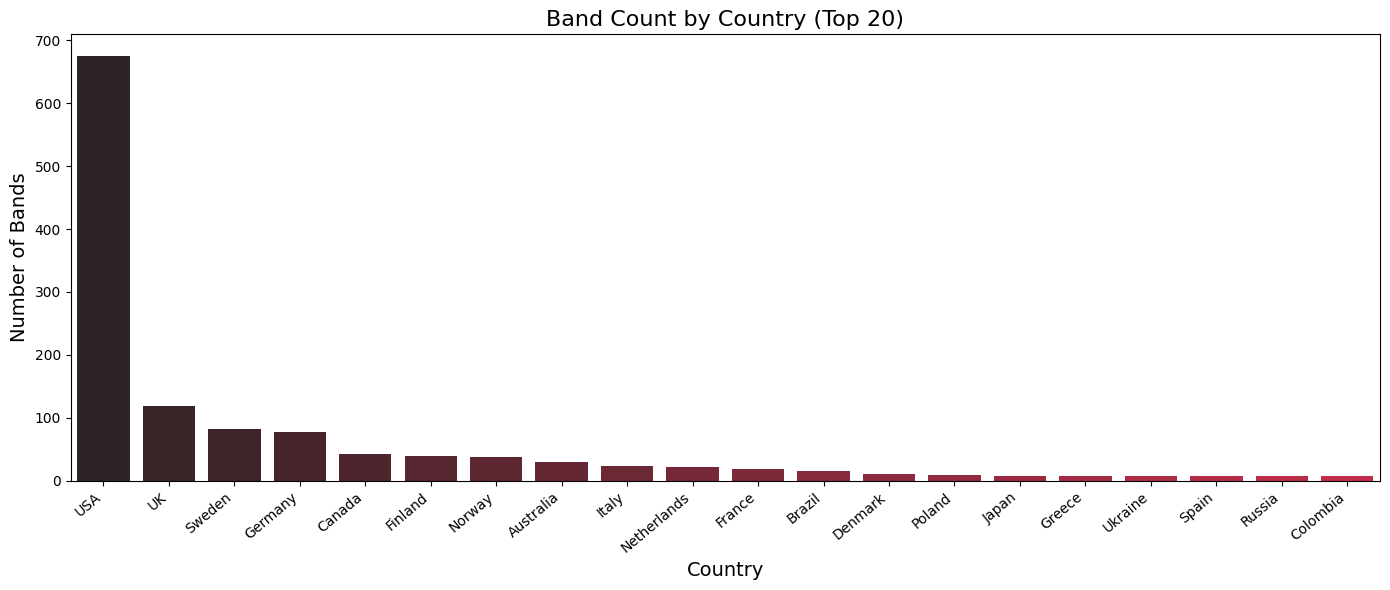

    country  band_count
        USA         676
         UK         119
     Sweden          82
    Germany          77
     Canada          42
    Finland          39
     Norway          37
  Australia          29
      Italy          24
Netherlands          22
     France          19
     Brazil          16
    Denmark          11
     Poland           9
      Japan           8
     Greece           8
    Ukraine           7
      Spain           7
     Russia           7
   Colombia           7


In [3]:
df_artists = pd.read_sql("SELECT country, COUNT(*) as band_count FROM artists GROUP BY country ORDER BY band_count DESC LIMIT 20", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_artists, x='country', y='band_count', hue='country', palette='dark:crimson', legend=False)
plt.title('Band Count by Country (Top 20)', fontsize=16)
plt.xlabel('Country', fontsize=14)
plt.ylabel('Number of Bands', fontsize=14)
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print(df_artists.to_string(index=False))

---

### Release Year Distribution

The corpus spans from 1968 to 2026. The earliest release included is the song *Helter Skelter* by The Beatles, and the first true "metal" album is Black Sabbath's self-titled album from 1970. Release count grows steadily through the 70s, 80s, and 90s before peaking in 2004, with 266. The decline starting in the mid-2010's is somewhat misleading; it likely reflects a selection bias towards the releases catalogued online and used in this project, not a decline in metal output. The album *Painkiller* (1990) by Judas Priest has had 36 years to earn its reputation; a 2022 release hasn't had that time yet.

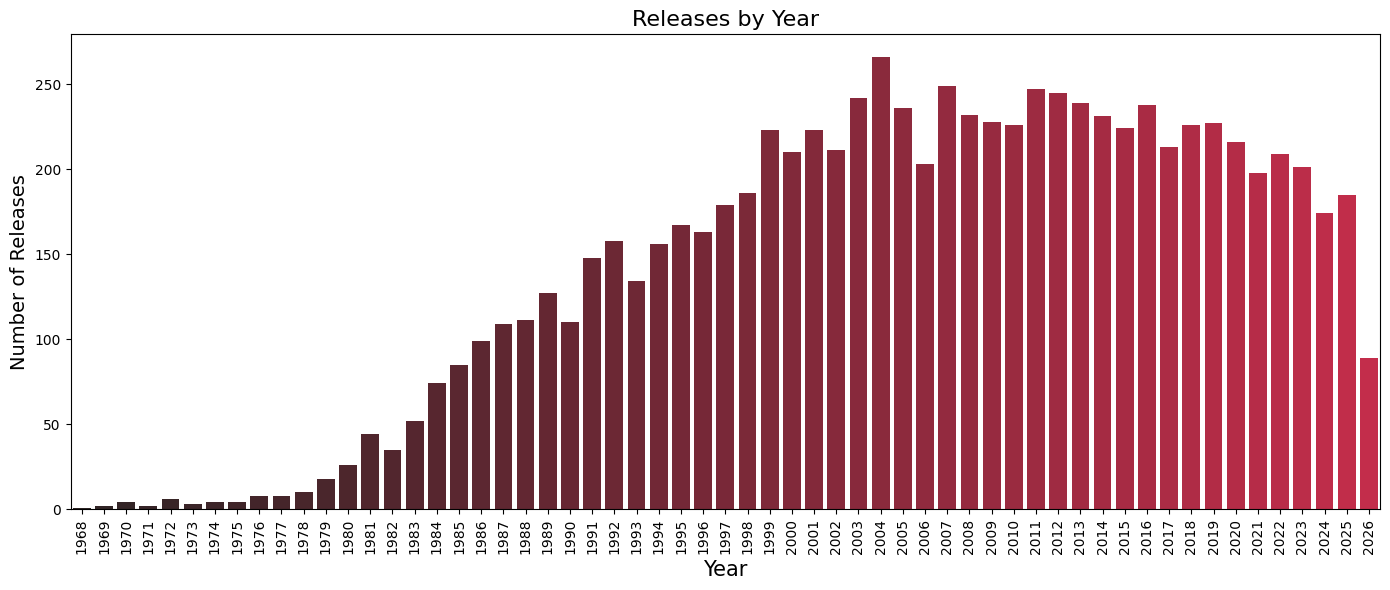

Earliest release: 1968
Most recent release: 2026
Most active year: 2004 (266 releases)


In [4]:
df_years = pd.read_sql("""
    SELECT year, COUNT(*) as release_count
    FROM releases
    WHERE year != 'Unknown'
    GROUP BY year
    ORDER BY year
""", conn)

df_years['year'] = pd.to_numeric(df_years['year'], errors='coerce')
df_years = df_years.dropna()

plt.figure(figsize=(14, 6))
sns.barplot(data=df_years, x='year', y='release_count', hue='year', palette='dark:crimson', legend=False)
plt.title('Releases by Year', fontsize=16)
plt.xlabel('Year', fontsize=15)
plt.ylabel('Number of Releases', fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Earliest release: {int(df_years['year'].min())}")
print(f"Most recent release: {int(df_years['year'].max())}")
print(f"Most active year: {int(df_years.loc[df_years['release_count'].idxmax(), 'year'])} ({df_years['release_count'].max()} releases)")

---

### Vocalist Gender Breakdown

95% of the releases in this dataset feature male vocalists; releases with female vocalists make up almost 5%, and bands with both male and female vocalists make up a fraction of a percent. Metal has always been a male-dominated music genre, and I made a deliberate effort to seek out bands with female vocalists to improve representation in this dataset. 

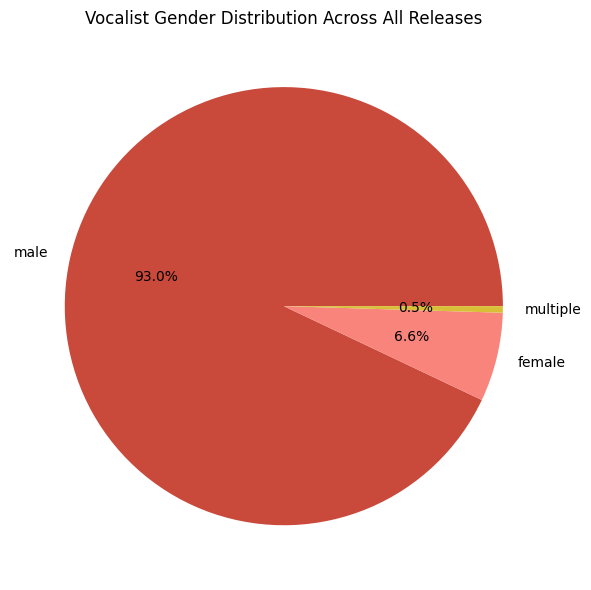

vocalist_gender  count
           male   7758
         female    548
       multiple     40


In [5]:
df_gender = pd.read_sql("""
    SELECT vocalist_gender, COUNT(*) as count
    FROM releases
    GROUP BY vocalist_gender
    ORDER BY count DESC
""", conn)

plt.figure(figsize=(8, 6))
plt.pie(df_gender['count'], labels=df_gender['vocalist_gender'], autopct='%1.1f%%', 
        colors = ['#C9493B', '#F9847B', '#D8BF37', '#D8D8D8'])
plt.title('Vocalist Gender Distribution Across All Releases', fontsize=12)
plt.tight_layout()
plt.show()

print(df_gender.to_string(index=False))

---

### Vocalist Gender by Subgenre

Which subgenres have the most female representation? For this question, I used Discogs' more specific subgenre classification system. 

Of the eight subgenres with the highest female vocalist representation, only one maps directly to one of the ten named subgenres in this analysis: Nu Metal. Symphonic Metal (48.3%) and Gothic Metal (44.8%) both significantly exceed Nu Metal's representation, but were collapsed into the broader categories of Power Metal and Other. 

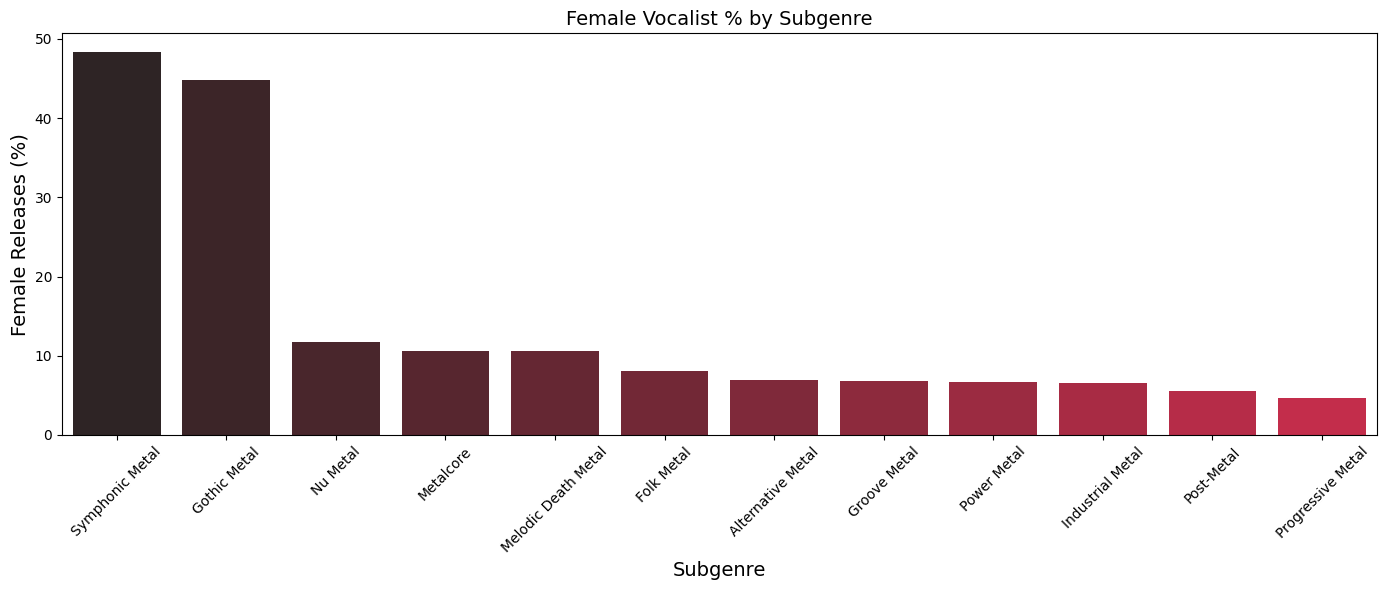

      subgenre_name  female_releases  male_releases  total_releases  female_pct
    Symphonic Metal              128            134             265        48.3
       Gothic Metal               69             85             154        44.8
           Nu Metal               55            414             469        11.7
          Metalcore               72            606             682        10.6
Melodic Death Metal               20            168             189        10.6
         Folk Metal               10            112             123         8.1
  Alternative Metal               19            251             271         7.0
       Groove Metal                6             82              88         6.8
        Power Metal               29            399             430         6.7
   Industrial Metal                5             72              77         6.5
         Post-Metal                4             67              71         5.6
  Progressive Metal               24    

In [6]:
df_gender_subgenre = pd.read_sql("""
    SELECT 
        subgenre_name,
        SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) as female_releases,
        SUM(CASE WHEN vocalist_gender = 'male' THEN 1 ELSE 0 END) as male_releases,
        COUNT(*) as total_releases,
        ROUND(100.0 * SUM(CASE WHEN vocalist_gender = 'female' THEN 1 ELSE 0 END) / COUNT(*), 1) as female_pct
    FROM release_subgenres
    GROUP BY subgenre_name
    HAVING total_releases > 10
    AND subgenre_name LIKE '%Metal%' --This analysis uses Discogs' more granular subgenre list, so filtering for having "Metal" in the name prevents other genres like J-Pop or Ambient from appearing
    AND female_releases > 0
    ORDER BY female_pct DESC
    LIMIT 12
""", conn)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_gender_subgenre, x='subgenre_name', y='female_pct',
            hue='subgenre_name', palette='dark:crimson', legend=False)
plt.title('Female Vocalist % by Subgenre', fontsize=14)
plt.xlabel('Subgenre', fontsize=14)
plt.ylabel('Female Releases (%)', fontsize=14)
plt.tick_params(axis='x', rotation=45)
#plt.axhline(y=df_gender_subgenre['female_pct'].mean(), color='gray', linestyle='--', label='Average')
#plt.legend()
plt.tight_layout()
plt.show()

print(df_gender_subgenre[['subgenre_name', 'female_releases', 'male_releases', 'total_releases', 'female_pct']].to_string(index=False))


---

The dataset is large, geographically and gender-diverse, and deliberately curated. With that context established, the real questions begin.

---

## Universal Metal Vocabulary

### The 10 Most Common Words in Metal Music

"What are the most common words used in metal?" was the question that started this whole project, and that is the first thing I want to answer.

,Word,Total
1,life,56955
2,world,38705
3,feel,35614
4,eyes,31603
5,love,30893
6,death,30653
7,die,29575
8,night,27777
9,nothing,27038
10,blood,27005


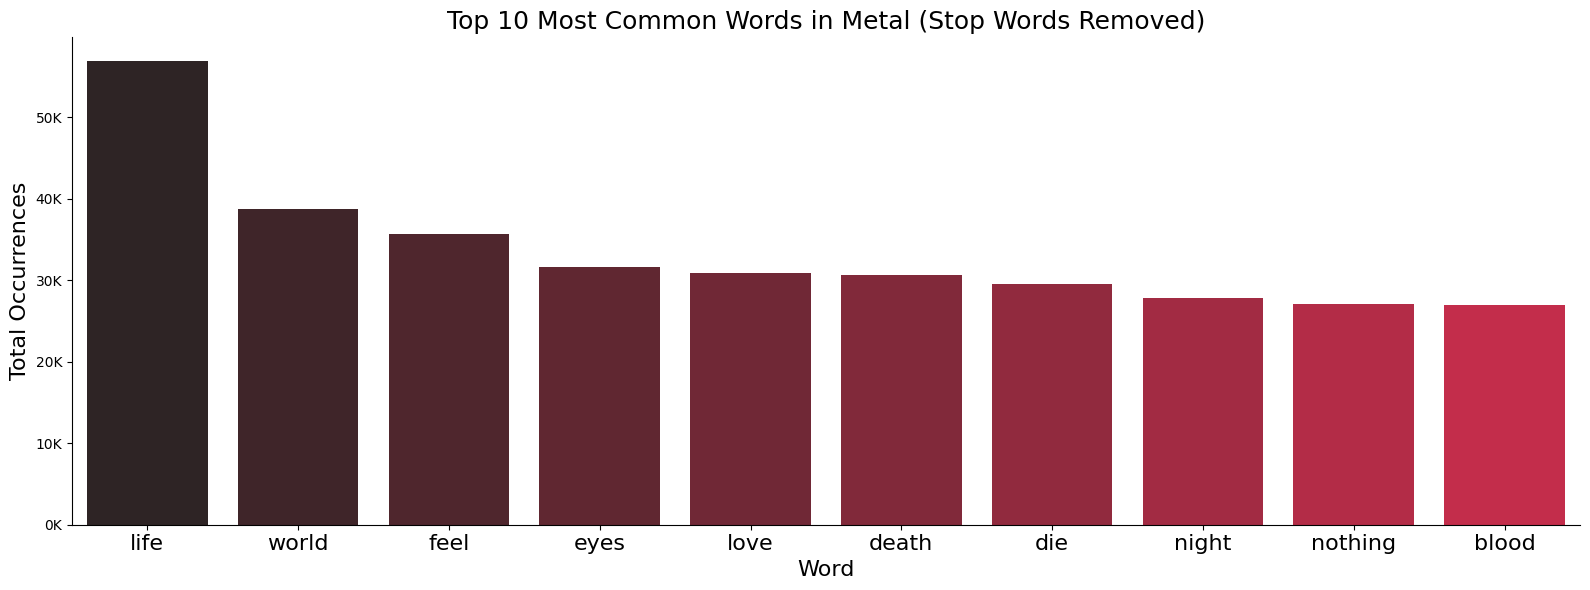

In [7]:
stop_words = {
    'the', 'and', 'to', 'of', 'a', 'in', 'i', 'you', 'my', 'is', 'it', 
    'me', 'for', 'on', 'we', 'no', 'that', 'will', 'your', 'all', 'this', 
    'are', 'be', 'with', 'not', 'but', 'so', 'as', 'have', 'from', 'or', 
    'an', 'at', 'by', 'they', 'do', 'if', 'was', 'their', 'our', 'its', 
    'been', 'has', 'her', 'him', 'his', 'she', 'he', 'can', 'what', 'when', 
    'there', 'than', 'more', 'up', 'out', 'am', 'into', 'us', 'would', 
    'who', 'which', 'had', 'were', 'one', 'about', 'just', 'now', 'like', 
    'how', 'know', 'get', 'go', 'come', 'see', 'time', 'way', 'could', 
    'make', 'take', 'through', 'over', 'back', 'down', 'then', 'only', 
    'some', 'other', 'new', 'also', 'two', 'may', 'after', 'where', 'much', 
    'before', 'here', 'away', 'still', 'even', 'never', 'those', 'them', 
    'these', 'such', 'own', 'too', 'very', 'well', 'did', 'should', 'while', 
    'off', 'again', 'same', 'upon', 'every', 'between', 'under', 'let',
    'don', 'got', 'say', 'said', 'til', 'cause', 'ain', 'gonna', 'wanna',
    'gotta', 'yeah', 'oh', 'ah', 'ha', 'na', 'la', 'da', 'wo', 'hey',
    'ooh', 'uh', 'whoa', 'mmm', 'huh', 'em', 'im', 've', 're', 'll',
    'i\'m', 'it\'s', 'you\'re', 'he\'s', 'she\'s', 'they\'re', 'we\'re', 
    'we\'ve', 'you\'ve', 'they\'ve', 'don\'t', 'i\'ll', 'he\'ll', 'she\'ll',
    'we\'ll', 'can\'t', 'i\'ve', 'there\'s', 'won\'t'
}

df_meaningful = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful['total'] = df_meaningful[subgenres].sum(axis=1)
df_meaningful = df_meaningful.sort_values('total', ascending=False)

TOP_N = 10  # change this and rerun to see more/fewer words

df_display = df_meaningful[['word', 'total']].head(TOP_N).copy()
df_display.columns = ['Word', 'Total']
df_display = df_display.reset_index(drop=True)
df_display.index += 1
display(df_display)

top_N_used = df_meaningful.head(TOP_N)
plt.figure(figsize=(16, 6))
sns.barplot(data=top_N_used, x='word', y='total', hue='word', palette='dark:crimson', legend=False)
plt.title(f'Top {TOP_N} Most Common Words in Metal (Stop Words Removed)', fontsize=18)
plt.xlabel('Word', fontsize=16)
plt.ylabel('Total Occurrences', fontsize=16)
plt.xticks(rotation=0, ha='center', fontsize=16)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000:.0f}K'))
sns.despine()
plt.tight_layout()
plt.show()

These 10 words are so far above and beyond what I was hoping to find. Almost a decade ago, I made a silly little program to disprove someone else's claim (See [README.md](README.md) if you need context), and now the same question has led me to make this project and find this beautiful list. So much can be inferred from just these 10 words. 

First, and most obvious, the clear distinction between 5 positive-leaning words on top and 5 negative-leaning words on the bottom. Second, **'life'** and 'love' appear more commonly than 'death' and 'die'. And those are just surface-level findings. For example, you can use 'life' in a positive or a negative context (i.e., "this life is beautiful" or "this life sucks"), but you can't really use 'death' or 'die' in a positive one. A sentiment analysis could reveal *how* 'life' is really used and what metal music thinks about being alive.

This simple query answered my decade-old question and made me so excited to keep exploring. 

---

### Metal Vocabulary Word Cloud

From that top 10 word analysis, 'life' and 'love' coming before 'death' and 'die' made me curious about the overall sentiment of metal lyrics. To explore that, I used VADER, a sentiment analysis library, to assign a sentiment score to each word. The words are sized by usage frequency and colored by sentiment on a continuous scale: positive (green) to neutral (white) to negative (red). Stop words ('the', 'and') are removed. I've applied a manual override to words like 'blood' and 'live', which appear as neutral in the VADER lexicon, but do carry meaning in this context.

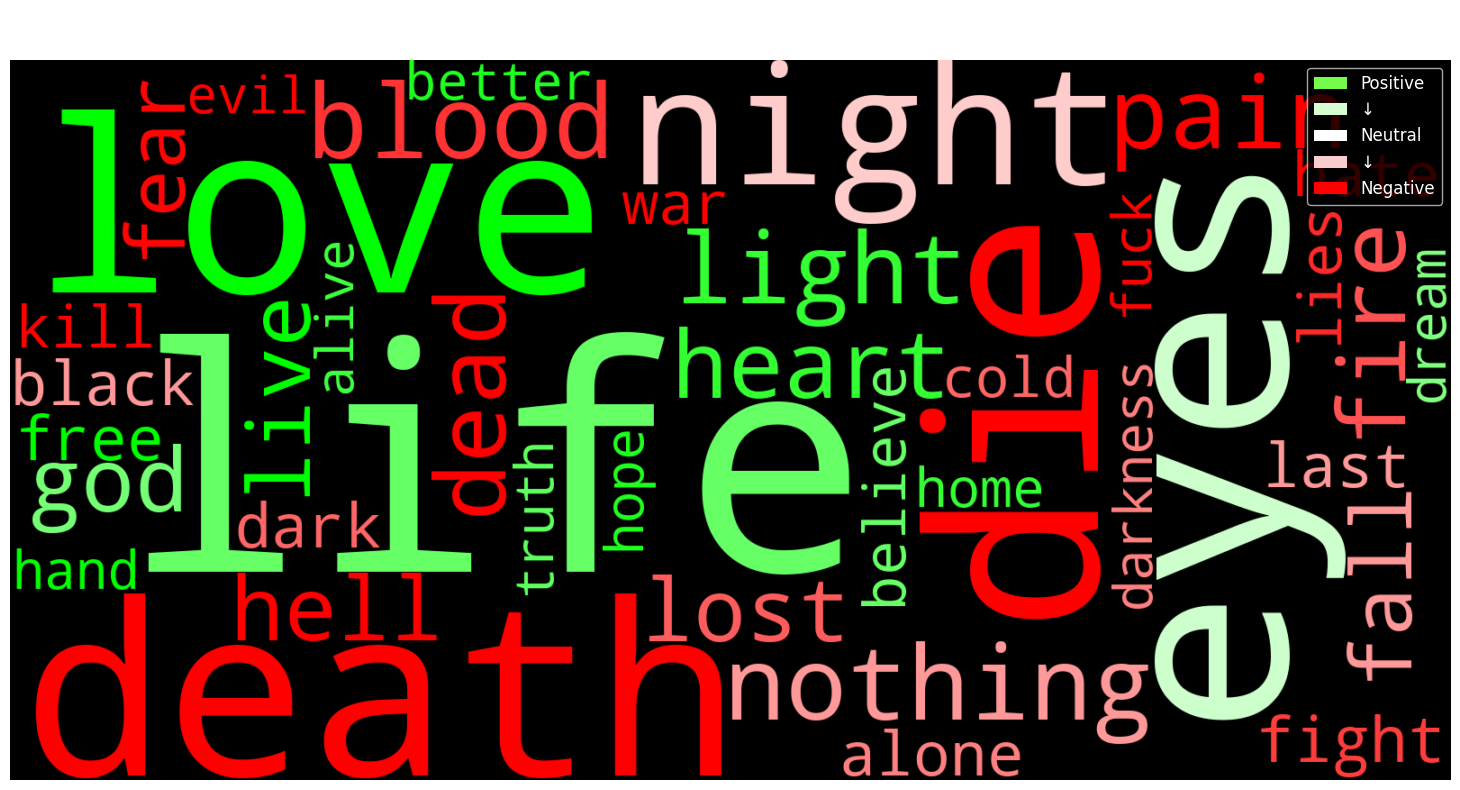

In [8]:
from wordcloud import WordCloud
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.colors as mcolors

sia = SentimentIntensityAnalyzer()

df_meaningful100 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful100['total'] = df_meaningful100[subgenres].sum(axis=1)
df_meaningful100 = df_meaningful100.sort_values('total', ascending=False).head(100)

# Scores from -1.0 to 1.0, overriding VADER where it falls short
metal_overrides = {
    'life':     0.3, # mostly positive, but can be used in a negative context
    'night':   -0.1, # dark, a little atmospheric
    'nothing': -0.2, # pessimistic, but can be used in a positive context
    'eyes':     0.1, 
    'light':    0.4,
    'black':   -0.2,
    'blood':   -0.4, 
    'live':     0.6,
    'dark':    -0.3,
    'fall':    -0.2,
    'heart':    0.4,
    'believe':  0.3,
    'cold':    -0.3,
    'last':    -0.2,
    'home':     0.4   
}

def get_sentiment_color(word, font_size, position, orientation, random_state=None, **kwargs):
    if word.lower() in metal_overrides:
        score = metal_overrides[word.lower()]
    else:
        score = sia.polarity_scores(word)['compound']
    if score >= 0.05:
        clamped = min(score, 0.5) / 0.5
        intensity = int(clamped * 255)
        return f'rgb({255 - intensity}, 255, {255 - intensity})'
    elif score <= -0.05:
        clamped = min(abs(score), 0.5) / 0.5
        intensity = int(clamped * 255)
        return f'rgb(255, {255 - intensity}, {255 - intensity})'
    else:
        return 'rgb(255, 255, 255)'

def get_final_score(word):
    if word.lower() in metal_overrides:
        return metal_overrides[word.lower()]
    return sia.polarity_scores(word)['compound']

df_meaningful100['vader_score'] = df_meaningful100['word'].apply(get_final_score)
df_sentiment_filtered100 = df_meaningful100[df_meaningful100['vader_score'].abs() >= 0.1]

word_freq = dict(zip(df_sentiment_filtered100['word'], df_sentiment_filtered100['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=100,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Metal — Colored by Sentiment', fontsize=20, color='white', pad=20)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right', 
           facecolor='black', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()

At a glance, the balance between negative to positive is nearly equal. Negative words are more numerous, but the most frequently used words tend to lean positive.

At the risk of being overcrowded, here is the same word cloud, populated with nearly 10 times the words for those who want to explore:

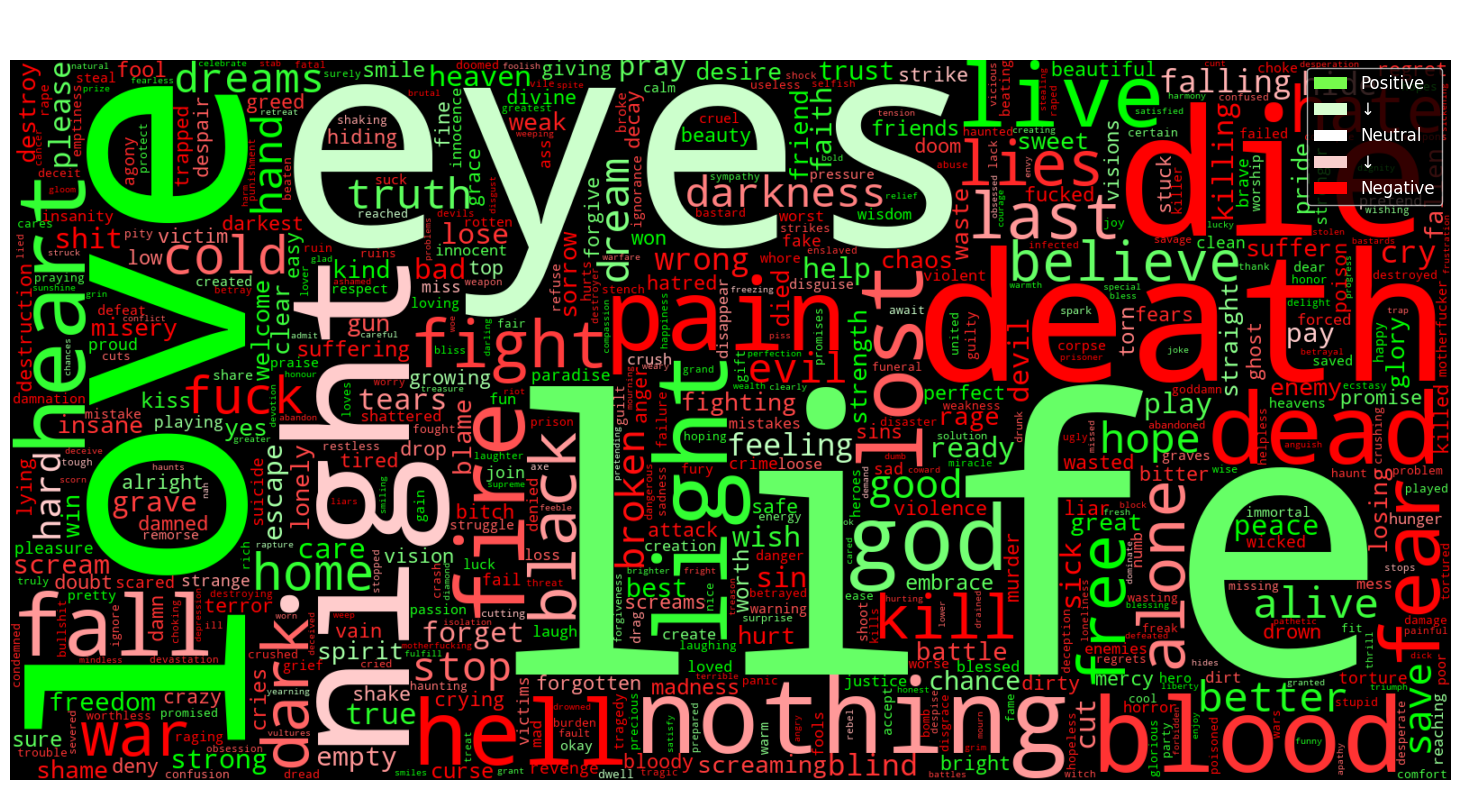

In [9]:
df_meaningful2000 = df_words[~df_words['word'].isin(stop_words)].copy()
df_meaningful2000['total'] = df_meaningful2000[subgenres].sum(axis=1)
df_meaningful2000 = df_meaningful2000.sort_values('total', ascending=False).head(2500)

df_meaningful2000['vader_score'] = df_meaningful2000['word'].apply(get_final_score)
df_sentiment_filtered2000 = df_meaningful2000[df_meaningful2000['vader_score'].abs() >= 0.1]

word_freq = dict(zip(df_sentiment_filtered2000['word'], df_sentiment_filtered2000['total']))

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=800,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Metal — Colored by Sentiment', fontsize=20, color='white', pad=20)

# Add a legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right', 
           facecolor='black', labelcolor='white', fontsize=12)

plt.tight_layout()
plt.show()

As a completely unscientific aside, the average pixel color of the word cloud above is rgb(59, 53, 25). Because of how equally-matched red and green appear, I took 6 screenshots of it (Word clouds randomize placement each render), fed them into [matkl's Average Color App](https://matkl.github.io/average-color/), averaged them out, and the result was a red value of 59 and a green value of 53: a measly 11% difference between the two in favor of negative words. Again, completely unscientific. Word frequency, length, and character usage massively affect pixel count, but, yes, in this graph, red does land on top.

---

### Most Common Words by Subgenre

Because some subgenres are more equal than others in popularity and representation in this dataset, classic heavy metal could dominate the overall numbers. Maybe heavy metal talks about life a lot, but the rest don't. Let's break it down by subgenre:

In [10]:
results = {}
for subgenre in subgenres:
    df_sub = df_words[~df_words['word'].isin(stop_words)].copy()
    df_sub = df_sub[df_sub[subgenre] > 0]
    df_sub = df_sub.sort_values(subgenre, ascending=False).head(5)
    results[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results:
        words = [w for w, c in results[subgenre]]
        rows.append([subgenre] + words)

df_transposed = pd.DataFrame(rows, columns=['subgenre', '#1', '#2', '#3', '#4', '#5'])
df_transposed.index = range(1, len(df_transposed) + 1)

display(df_transposed.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,life,love,world,night,feel
2,thrash,life,death,world,die,blood
3,death,life,death,blood,world,dead
4,black,death,blood,life,night,black
5,groove,life,inside,death,nothing,eyes
6,progressive,life,world,eyes,light,feel
7,doom,life,eyes,world,love,death
8,power,life,world,night,light,fire
9,glam,love,baby,night,want,need
10,nu,life,feel,want,nothing,inside


11 of the 14 subgenres use 'life' as the most common meaningful word, and amazingly, death metal is among those 11. The three that don't are:\
**Black metal**, which uses 'death',\
**Glam metal**, which is apparently all about 'love', and\
**Alt metal**, which uses 'feel'.

The entire 5x14 table consists of only 19 unique words. The subgenre that sticks out the most is glam metal, with 'love', 'baby', 'night', 'want', and 'need'; two of which ('baby' and 'need') are entirely unique to glam metal. This reflects glam metal's commercial, radio-friendly image.

Subgenre-specific words among the top 5 used meaningful words include:\
**Glam metal**:   'baby' and 'need'\
**Thrash metal**: 'die'\
**Gothic metal**: 'heart'\
**Death metal**:  'dead'\
**Black metal**:  'black'\
**Power metal**:  'fire'

The shared stylistic origins between nu metal, alt metal, and metalcore show up in the data: all three share 'life' and 'feel' as their top two meaningful words, though not consistently in that order. These genres all took influence from late-'90s alternative rock, and the vocabulary reflects it.

---

### Most Unique Words by Subgenre

A more sophisticated approach would rank words by how disproportionately often they appear in one subgenre versus all others. That returns a messy (but funny) result, for reasons I'll discuss:

In [11]:
results_unique = {}
for subgenre in subgenres:
    df_sub = df_words[~df_words['word'].isin(stop_words)].copy()
    other_subgenres = [s for s in subgenres if s != subgenre]
    df_sub['other_total'] = df_sub[other_subgenres].sum(axis=1)
    df_sub['ratio'] = df_sub[subgenre] / (df_sub['other_total'] + 1)
    df_sub = df_sub[df_sub[subgenre] >= 20]
    df_sub = df_sub.sort_values('ratio', ascending=False).head(5)
    results_unique[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results_unique:
        words = [w for w, c in results_unique[subgenre]]
        rows.append([subgenre] + words)

df_transposed_unique = pd.DataFrame(rows, columns=['subgenre', '#1', '#2', '#3', '#4', '#5'])
df_transposed_unique.index = range(1, len(df_transposed_unique) + 1)

display(df_transposed_unique.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,piep,latten,nai,nanook,tico
2,thrash,nioj,mulambo,ooma,crippler,nevertrust
3,death,ouk,erebos,arra,amerika,virvum
4,black,lok'tar,saatanan,blashyrkh,nymphetamine,jumalan
5,groove,iou,babymetal,cowboy,volatile,sickest
6,progressive,livable,demolished,marigold,cantations,cygnus
7,doom,meddlesome,mantia,veem,ouvem,cheiram
8,power,nekron,liber,dargor,kunor,hargor
9,glam,kix,stevie,bop,feelgood,suzi
10,nu,stressin'out,uation,fittin,shari,rowboat


My analysis runs using raw frequency, meaning that 100 mentions of the word 'the' in a song adds 100 ticks to that subgenre's 'the' value. Similarly, **71** mentions of 'piep', an onomatopoeia for a phone notification, in the song *Piep Piep Piep* by the German band The Butcher Sisters adds 71 ticks to heavy metal's 'piep' row value. Other notable examples include:\
**99** mentions of 'pogo' in System of a Down's *Bounce*\
**77** mentions of 'spreck' in Infectious Groove's *Spreck*\
**66** mentions of 'barsch' in The Butcher Sisters' *Barsch*\
**35** mentions of 'feelgood' in Mötley Crüe's *Dr. Feelgood*\
**20** mentions of 'cigaro' in System of a Down's *Cigaro*\
**26** mentions of 'kix' in Kix's *Kix Are For Kids*

The subgenre-unique words table is *technically* accurate, but holds little meaningful data. To focus on meaningful vocabulary, the table below increases the minimum word count from 20 to 100 mentions before it is eligible to appear and manually removes non-English words, onomatopoeia, and blatant artifacts of raw frequency. A more rigorous fix is planned for V2: ranking words by range (how many distinct songs use a word), which would remove the need for manual curation.

This table contains explicit language and references to violence, reflective of common lyrical themes in extreme metal subgenres.

In [12]:
TOP_N = 5  # <- change this number and rerun the cell (Shift+Return) to see more words per subgenre

manual_remove = {
    'nai', 'cyco', 'je', 'olen', 'jeg', 'ved', 'fra', 'skal',
    'seg', 'meg', 'ov', 'dod', 'nar', 'nah', 'ba', 'dop',
    'ayy', 'ist', 'y', 'ur', 'eg', 'hann', 'sem', 'kan',
    'ingen', 'det', 'av', 'og', 'que', 'durch', 'nu', 'mig', 
    'allt', 'von', 'med', 'tid', 'ja', 'kun', 'alt', 'niin',
    'doch', 'ihr', 'vid', 'wenn', 'mina', 'som', 'ei', 'vil',
    'blod', 'var', 'om', 'liv', 'ett', 'fran', 'en', 'han',
    'och', 'har', 'att', 'jag', 'dich', 'din', 'pa', 'ut', 'er', 
    'skall', 'wir', 'uns', 'dir', 'sein', 'min', 'dar', 'sen',
    'mehr', 'oss', 'den', 'kuin', 'aus', 'vi', 'mitt', 'sie', 'jo',
    'lai', 'nicht', 'zu', 'auf', 'mein', 'ir', 'und', 'ser', 'ein', 
    'um', 'das', 'mir', 'mich', 'der', 'ar', 'dem', 'wie', 'sa',
    'du', 'mit', 'ich', 'fur', 'se', 'es', 'ay', 'ta', 'ni', 'dei',
    'k', 'gor', 'pas', 'il', 'che', 'di', 'o', 'de', 'to', 'v',
    'mot', 'ye', 'et', 'est', 'te', 'oooh', 'ad', 'e', 'tu', 'r', 
    'un', 'n', 'mu', 'x', 'le', 'l', 't', 'lo', 'mi', 'u', 'c',
    'ne', 'm', 'p', 'd', 'b', 'f', 's', 'les', 'mon', 'th', 'na',
    'til'
}
# Although 'den' is a word in English, I believe its appearance as a uniquely black metal word 
# is most likely because it is also a Swedish, Danish, and Norwegian word that translates to 
# the much more common 'it' or 'that'.

results_unique = {}
for subgenre in subgenres:
    df_sub = df_words[
        ~df_words['word'].isin(stop_words) &
        ~df_words['word'].isin(manual_remove)
    ].copy()
    other_subgenres = [s for s in subgenres if s != subgenre]
    df_sub['other_total'] = df_sub[other_subgenres].sum(axis=1)
    df_sub['ratio'] = df_sub[subgenre] / (df_sub['other_total'] + 1)
    df_sub = df_sub[df_sub[subgenre] >= 100]
    df_sub = df_sub.sort_values('ratio', ascending=False).head(TOP_N)
    results_unique[subgenre] = list(zip(df_sub['word'], df_sub[subgenre]))

rows = []
for subgenre in subgenres:
    if subgenre in results_unique:
        words = [w for w, c in results_unique[subgenre]]
        words += [''] * (TOP_N - len(words)) #Displays empty instead of 'None' if run out of words
        rows.append([subgenre] + words)

df_transposed_unique = pd.DataFrame(rows, columns = ['subgenre'] + [f'#{i}' for i in range(1, TOP_N + 1)])
df_transposed_unique.index = range(1, len(df_transposed_unique) + 1)

display(df_transposed_unique.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,babe,gypsy,london,rock,rocking
2,thrash,mosh,thrash,thrashing,beer,aggression
3,death,cadaver,butchery,fluids,innards,organs
4,black,inn,nocturnal,satanic,thou,satan
5,groove,test,pick,sick,does,shit
6,progressive,drifting,view,maze,ocean,cosmic
7,doom,lucifer,doom,arise,beauty,thee
8,power,pirate,dominus,sanctus,dwarves,rum
9,glam,blues,boys,girls,mama,baby
10,nu,jah,y'all,mic,rollin,pogo


Much better. With raw frequency artifacts removed, it provides a much better view of the unique vocabulary of each subgenre. It isn't perfect, however. The distinctive vocabulary isn't universal across each subgenre: power metal's list is topped by 'pirate', which says more about a handful of pirate-themed bands in the genre than about power metal as a whole. Even so, the table does show meaningful data, and really does reinforce some stereotypes I've held about subgenres:

- **Nu metal** carried a rap influence into metal when it emerged, and with it came rap vocabulary. 'y'all', 'mic', 'rollin' don't look like they belong with the rest of this list, and that's what made nu metal unique.
- **Thrash metal** likely got its name from the song *Metal Thrashing Mad* by Anthrax, so 'mosh', 'thrash', and 'thrashing' being the top three unique words for thrash metal is perfect.
- **Death metal** (Very broadly speaking) is shock rock taken to its natural extreme. The lyrics often don't matter; if they did, they would be enunciated, not growled. A band that I'm close with, Visceral Reaction, got their name from trying to find a name that would give people a "visceral reaction", so they cut out the middle man and just chose "Visceral Reaction".

This table has plenty more to explore, though how compelling it is likely depends on the reader's familiarity with the genre, so I'll leave further digging to the curious. If you'd like to see what comes after column 5, open the script above and adjust the variable at the top to however many columns you'd like to see.

Also, yes, 'pogo' is still in there. I'm not removing it.

---

### The Most "Metal" Words

Raw count can only get you so far. 10 years ago, my conclusion was that 'the' was the most-used word in metal, but we can go further: What words appear disproportionately often in metal lyrics compared to their usage in everyday English?

To answer this question, I need a baseline for everyday word frequency. I'm using [SUBTLEX-US](https://www.ugent.be/pp/experimentele-psychologie/en/research/documents/subtlexus), a frequency database built by Ghent University, using 51 million words from American movie and TV show subtitles.

In [13]:
subtlex = pd.read_csv('SUBTLEXfreqPoS-sorted.csv')
subtlex = subtlex[['Word', 'SUBTLWF']].copy()
subtlex.columns = ['word', 'general_freq_per_million']
subtlex['word'] = subtlex['word'].str.lower()
subtlex = subtlex.groupby('word', as_index=False)['general_freq_per_million'].sum()
subtlex = subtlex.sort_values('general_freq_per_million', ascending=False)
subtlex.head()

,word,general_freq_per_million
60181,you,41857.12
26138,i,39971.16
53703,the,29449.18
54347,to,22677.84
45602,s,20731.39


With a general-English baseline loaded, I can now compare each word's frequency in my metal corpus against its frequency in everyday speech to find which words are disproportionately "metal".

,word,metal_total,metal_freq_per_million,general_freq_per_million,metal_ratio
6654,blackened,1504,90.32,0.31,291.35
2912,forevermore,1042,62.57,0.53,118.06
2229,legions,945,56.75,0.71,79.93
3247,unholy,1666,100.05,1.33,75.22
1173,decay,2450,147.13,2.06,71.42
896,darkened,904,54.29,0.78,69.60
1733,demise,1907,114.52,1.71,66.97
4346,abyss,1908,114.58,1.76,65.10
1465,fading,2653,159.32,2.45,65.03
1212,collide,918,55.13,0.92,59.92


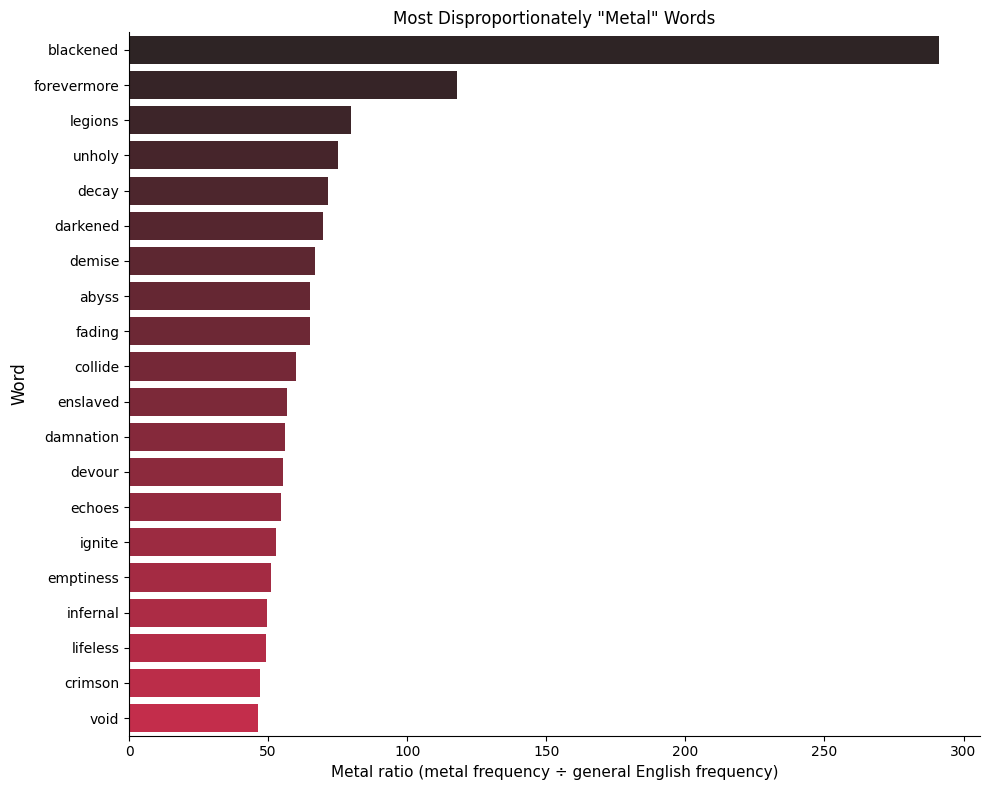

In [14]:
TOP_N = 20  # <- change this number and rerun the cell to see more/fewer words

df_words['metal_total'] = df_words[subgenres].sum(axis=1)
total_words_corpus = df_words[subgenres].sum().sum()
df_words['metal_freq_per_million'] = df_words['metal_total'] / total_words_corpus * 1_000_000

df_metal_vs_general = df_words.merge(subtlex, on='word', how='inner')
df_metal_vs_general = df_metal_vs_general[df_metal_vs_general['general_freq_per_million'] > 0]
df_metal_vs_general = df_metal_vs_general[df_metal_vs_general['metal_total'] >= 750]
df_metal_vs_general = df_metal_vs_general[~df_metal_vs_general['word'].isin(manual_remove)]

df_metal_vs_general['metal_ratio'] = (
    df_metal_vs_general['metal_freq_per_million'] / df_metal_vs_general['general_freq_per_million']
)
df_metal_vs_general = df_metal_vs_general.sort_values('metal_ratio', ascending=False)

# ///////////////////////// TABLE /////////////////
display(df_metal_vs_general.head(TOP_N)[['word', 'metal_total', 'metal_freq_per_million', 'general_freq_per_million', 'metal_ratio']].style.map(
    lambda x: 'font-weight: bold',
    subset=['word', 'metal_ratio']
).format({
    'metal_freq_per_million': '{:.2f}',
    'general_freq_per_million': '{:.2f}',
    'metal_ratio': '{:.2f}',
}))

# /////////////////////// VISUALIZATION ////////////
top_N_words = df_metal_vs_general.head(TOP_N).sort_values('metal_ratio', ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_N_words, x='metal_ratio', y='word', palette='dark:crimson', ax=ax, hue='word', legend=False)
ax.set_xlabel('Metal ratio (metal frequency ÷ general English frequency)', fontsize=11)
ax.set_ylabel('Word', fontsize=12)
ax.set_title('Most Disproportionately "Metal" Words')
sns.despine()
plt.tight_layout()
plt.show()

This returns a list of words that I, as a metalhead, would like to say matches my own sense of the genre pretty well. It returns **'blackened'** as the most disproportionately metal word, which I would agree with. 'Blackened' is such an essentially metal word that it transcends lyrics; a band that plays a non-black metal style but has strong black metal influence can be described as "blackened-". Blackened death metal, blackened crust punk, blackened thrash metal, etc.. 

Other words high on the list tend to cluster around themes of corruption (decay, fading, echoes, darkened), hellfire and damnation (unholy, abyss, damnation, ignite, legions, infernal), and nihilism (demise, emptiness, lifeless, void, abyss)

---

### Most "Metal" Word Cloud

A word cloud makes the overall sentiment easier to see. Much easier.

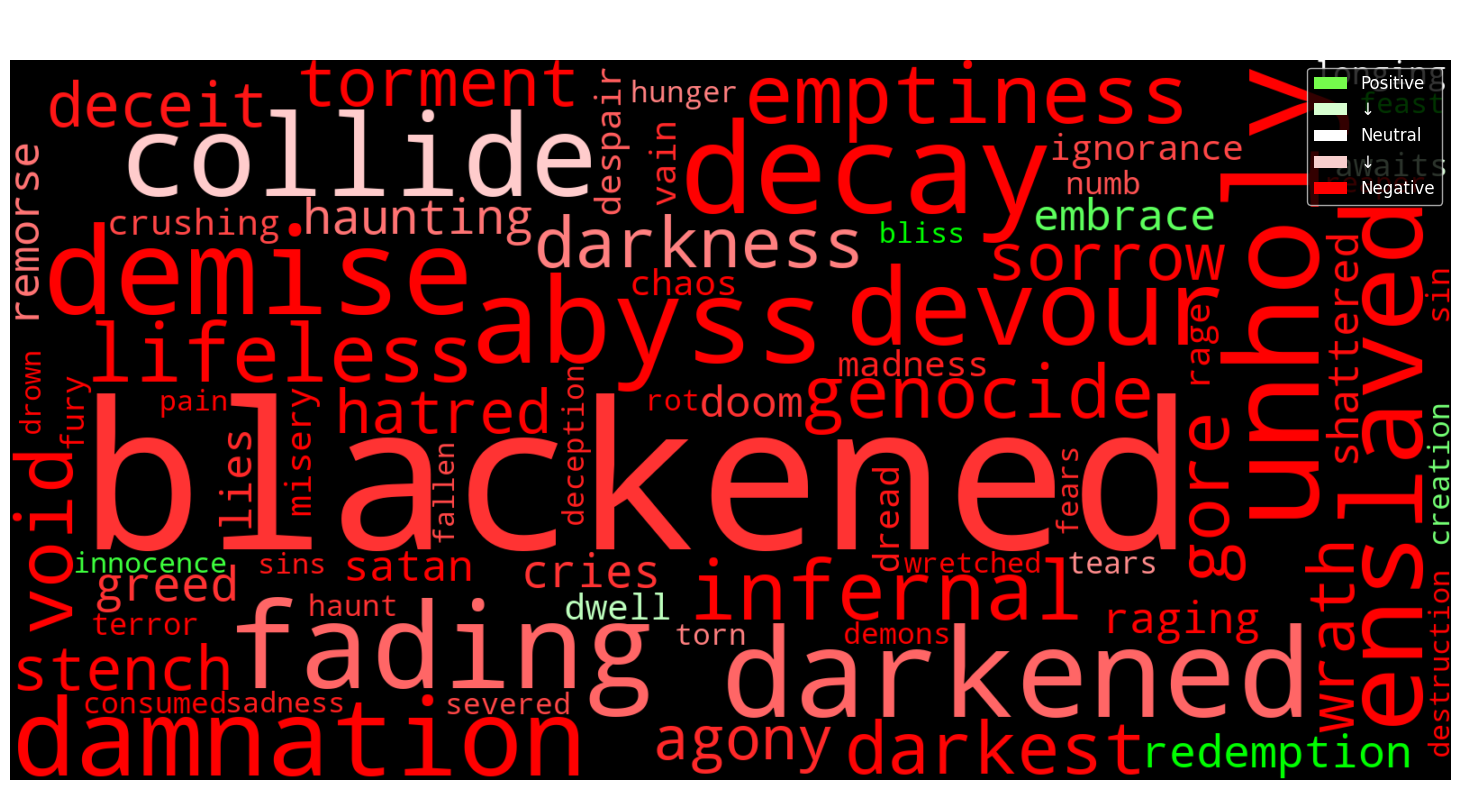

In [15]:
metal_overrides = {
    'life':     0.3, # mostly positive, but can be used in a negative context
    'night':   -0.1, # dark, a little atmospheric
    'nothing': -0.2, # pessimistic, but can be used in a positive context
    'eyes':     0.1, 
    'light':    0.4,
    'black':   -0.2,
    'blood':   -0.4, 
    'live':     0.6,
    'dark':    -0.3,
    'fall':    -0.2,
    'heart':    0.4,
    'believe':  0.3,
    'cold':    -0.3,
    'last':    -0.2,
    'home':     0.4,
    # Everything past here is for the most "metal" words
    'blackened': -0.4,
    'unholy':    -0.6, # strongly evil, religious
    'decay':     -0.5, # rot, deterioration
    'darkened':  -0.3,
    'demise':    -0.5, # death, downfall
    'abyss':     -0.5, # void, despair
    'fading':    -0.3, # decline
    'collide':   -0.1, 
    'enslaved':  -0.9, 
    'devour':    -0.5, # consumption, destruction
    'infernal':  -0.6, # hellish, evil
    'lifeless':  -0.7, # death, emptiness
    'void':      -0.5, # emptiness, nihilism
    'emptiness': -0.5, # hollow, despairing
    'satan':     -0.9, # doesn't get much worse than that
    'reaper':    -0.5, # 
    'feast':      0.5, # symbol of victory, indulgence
    'torment':   -0.7,
    'genocide':  -1.0, # okay, it does get a little worse than that
    'gore':      -0.5,
    'demons':    -0.6,
    'angels':     0.9,
    'wrath':     -0.7,
    'redemption': 0.6,
    'filth':     -0.6,
    'rot':       -0.5,
    'wretched':  -0.7,
    'nightmares':-0.7,
    'consumed':  -0.6,
    'plague':    -0.8
}

def has_sentiment_entry(word):
    # Returns True if the word has a real match in either metal_overrides
    # or VADER's lexicon, rather than just defaulting to a neutral 0.0 score:
    
    word_lower = word.lower()
    if word_lower in metal_overrides:
        return True
    # VADER's lexicon is exposed via sia.lexicon - a dict of word: score
    return word_lower in sia.lexicon

word_freq_metal_ratio_filtered = dict(
    zip(
        df_metal_vs_general[df_metal_vs_general['word'].apply(has_sentiment_entry)]['word'],
        df_metal_vs_general[df_metal_vs_general['word'].apply(has_sentiment_entry)]['metal_ratio']
    )
)

wordcloud_75_filtered = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=75,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq_metal_ratio_filtered)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_75_filtered, interpolation='bilinear')
plt.axis('off')
plt.title('Most Disproportionately "Metal" Words — Colored by Sentiment', fontsize=20, color='white', pad=20)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right',
           facecolor='black', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

For those who want to explore further, the word cloud below is the same, but more cluttered:

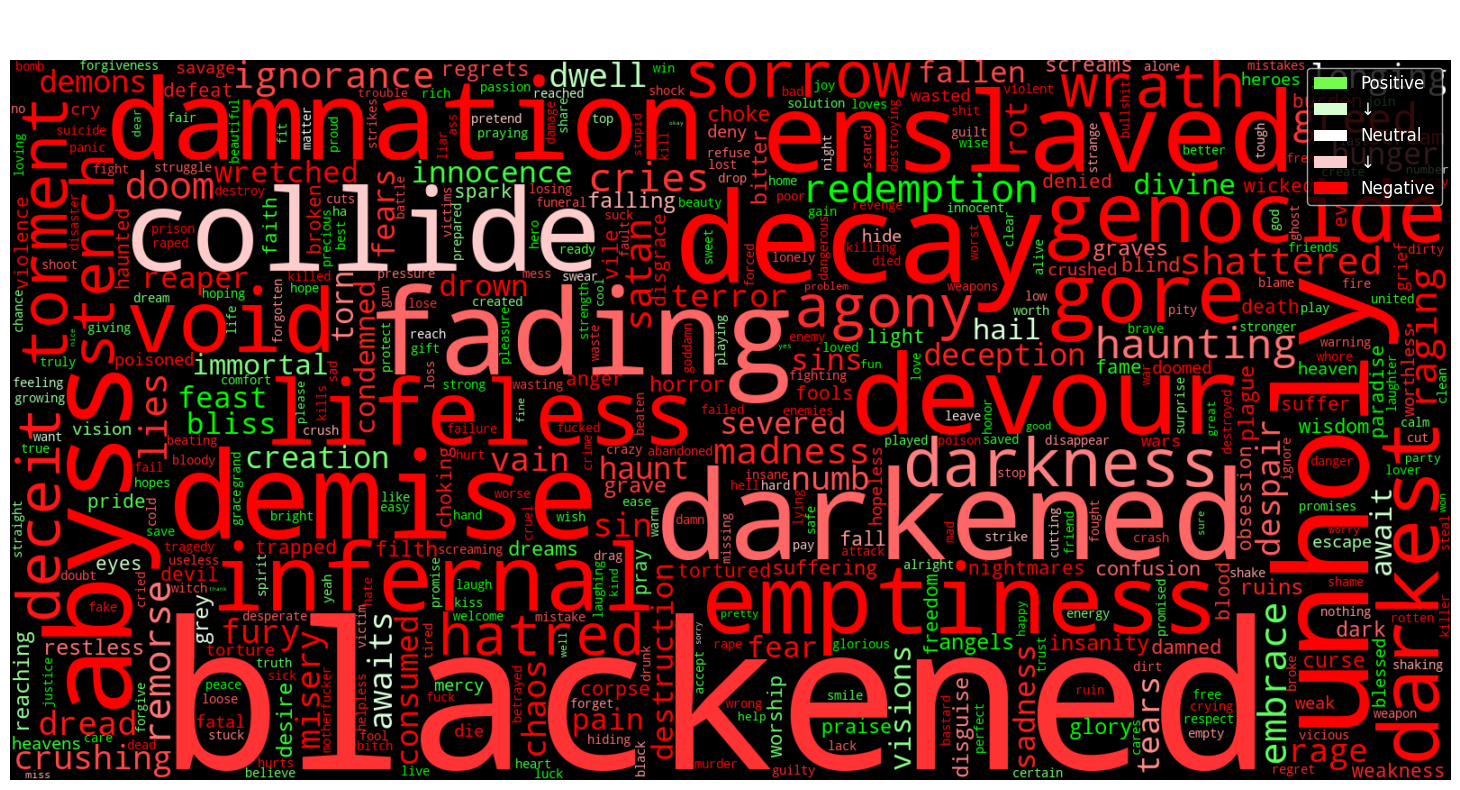

In [16]:
wordcloud_750_filtered = WordCloud(
    width=1600,
    height=800,
    background_color='black',
    max_words=750,
    prefer_horizontal=0.7,
    color_func=get_sentiment_color
).generate_from_frequencies(word_freq_metal_ratio_filtered)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud_750_filtered, interpolation='bilinear')
plt.axis('off')
plt.title('Most Disproportionately "Metal" Words — Colored by Sentiment', fontsize=20, color='white', pad=20)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#75fb4c', label='Positive'),
    Patch(facecolor='#d7fed0', label='↓'),
    Patch(facecolor='white', label='Neutral'),
    Patch(facecolor='#f7cecd', label='↓'),
    Patch(facecolor='red', label='Negative')
]
plt.legend(handles=legend_elements, loc='upper right',
           facecolor='black', labelcolor='white', fontsize=12)
plt.tight_layout()
plt.show()

I find the cluttered version the more interesting of the two, and potentially the most interesting of all the word clouds I've used. An overwhelming number of the most "metal" words are negative, with only islands of green in the sea of red. Unlike the Most Used Words word cloud, there aren't many words that dominate the screen. Sizes are more uniform, with a few exceptions. The colors themselves tell a story: the more extreme a word's sentiment is, the more vibrant its color becomes. Full vibrancy occurs starting at a 5/10, and this whole chart is exceptionally vibrant. 

---

### Most "Metal" Words by Subgenre

Same as with the Most Common Words table, breaking this down by subgenre reveals things the overall ranking can't.

In [17]:
TOP_N = 5

subgenre_totals = {sg: df_words[sg].sum() for sg in subgenres}

results_metal_by_subgenre = {}
for subgenre in subgenres:
    df_sub = df_metal_vs_general.copy()  # already filtered: general_freq > 0, manual removes applied
    
    df_sub['subgenre_freq_per_million'] = df_sub[subgenre] / subgenre_totals[subgenre] * 1_000_000
    df_sub['subgenre_metal_ratio'] = df_sub['subgenre_freq_per_million'] / df_sub['general_freq_per_million']
    
    df_sub = df_sub[df_sub[subgenre] >= 100]  # per-subgenre count threshold, lower than the 750 corpus-wide one since individual subgenres are smaller
    df_sub = df_sub.sort_values('subgenre_metal_ratio', ascending=False).head(TOP_N)
    
    results_metal_by_subgenre[subgenre] = list(zip(df_sub['word'], df_sub['subgenre_metal_ratio']))

rows = []
for subgenre in subgenres:
    if subgenre in results_metal_by_subgenre:
        words = [w for w, r in results_metal_by_subgenre[subgenre]]
        words += [''] * (TOP_N - len(words))  # blank if a subgenre runs short
        rows.append([subgenre] + words)

columns = ['subgenre'] + [f'#{i}' for i in range(1, TOP_N + 1)]
df_metal_by_subgenre = pd.DataFrame(rows, columns=columns)
df_metal_by_subgenre.index = range(1, len(df_metal_by_subgenre) + 1)

display(df_metal_by_subgenre.style.map(
    lambda x: 'font-weight: bold',
    subset=['#1']
))

,subgenre,#1,#2,#3,#4,#5
1,heavy,blackened,forevermore,legions,unholy,collide
2,thrash,blackened,legions,decay,demise,genocide
3,death,blackened,gore,unholy,decay,demise
4,black,blackened,legions,infernal,abyss,unholy
5,groove,bleed,self,rise,lies,pain
6,progressive,fading,echoes,void,emptiness,fade
7,doom,lucifer,arise,void,doom,sorrow
8,power,forevermore,blackened,fading,darkened,astray
9,glam,shout,rock,loving,burning,bang
10,nu,fading,scars,bleed,emptiness,fade


A few patterns immediately stick out: 'Blackened' isn't universally high like 'life' was. The word just dominates four genres and, interestingly, pops up in power metal.

The word 'forevermore', for being the second-most "metal" word, only tops one genre, and it's obviously **power metal**. No metalhead seeing that is surprised. 

The stylistic origins of **nu metal**, **alt metal**, and **metalcore** reveal themselves again: they all feature 'fading' as their most "metal" word. This time, they share it with **progressive** and **gothic metal**, too, though gothic metal prefers the verb's simple present tense, 'fade'.

**Doom metal** is content with its most used words. 'Lucifer', 'arise', and 'doom' all appeared in doom metal's Most Used Words list. The new additions to their Most "Metal" Words are 'void' and 'sorrow'.

Finally, **glam metal** is off just doing its thing again. 'Shout', 'rock', 'loving', 'burning', and 'bang' are all unique to glam metal alone and are action verbs that either invite audience participation or describe passion.

---

### The Most Universal Metal Word

So far, I've discovered that the most *used* word in metal is 'life' and the most *disproportionately* used word is 'blackened'. Both are great answers for my years-old question, but neither 'life' nor 'blackened' appear anywhere in the top 5 most "metal" words for *multiple* subgenres, as seen above. It hardly seems fair to give the most say to the subgenres with the most pure volume, so my final metric is the most "universal" metal word: What word appears *consistently* disproportionately higher in all metal subgenres?

,word,min_ratio_across_subgenres,metal_ratio
815,fade,30.65,43.57
1225,bleeds,23.07,33.95
7223,fades,21.24,37.00
1402,emptiness,20.91,51.01
1125,undone,19.21,33.92
2019,lifeless,18.24,49.19
937,bleed,17.39,37.24
1212,collide,17.05,59.92
5391,darkest,16.69,42.80
2043,veins,16.45,38.14


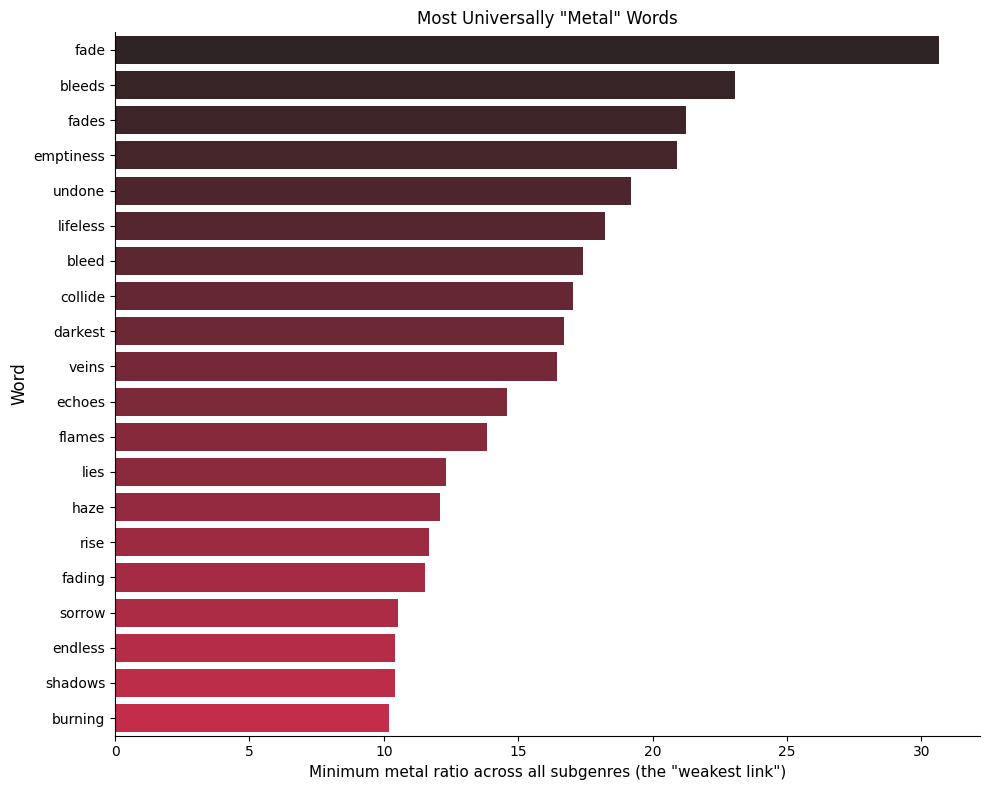

In [18]:
TOP_N = 20
subgenres_no_other = [sg for sg in subgenres if sg != 'other']
subgenre_totals = {sg: df_words[sg].sum() for sg in subgenres_no_other}
df_universal = df_metal_vs_general.copy()

for subgenre in subgenres_no_other:
    freq_per_million = df_universal[subgenre] / subgenre_totals[subgenre] * 1_000_000
    df_universal[f'{subgenre}_ratio'] = freq_per_million / df_universal['general_freq_per_million']

ratio_columns = [f'{sg}_ratio' for sg in subgenres_no_other]

# The floor: how "metal" is this word in its WEAKEST subgenre?
df_universal['min_ratio_across_subgenres'] = df_universal[ratio_columns].min(axis=1)
df_universal = df_universal[df_universal['metal_total'] >= 750]
df_universal = df_universal.sort_values('min_ratio_across_subgenres', ascending=False)

# ///////////////////////// TABLE /////////////////
display(df_universal[['word', 'min_ratio_across_subgenres', 'metal_ratio']].head(TOP_N).style.map(
    lambda x: 'font-weight: bold',
    subset=['word']
).format({
    'min_ratio_across_subgenres': '{:.2f}',
    'metal_ratio': '{:.2f}',
}))

# /////////////////////// VISUALIZATION ////////////
top_N_universal = df_universal.head(TOP_N).sort_values('min_ratio_across_subgenres', ascending=False)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top_N_universal, x='min_ratio_across_subgenres', y='word', palette='dark:crimson', ax=ax, hue='word', legend=False)
ax.set_xlabel('Minimum metal ratio across all subgenres (the "weakest link")', fontsize=11)
ax.set_ylabel('Word', fontsize=12)
ax.set_title('Most Universally "Metal" Words')
sns.despine()
plt.tight_layout()
plt.show()

The word that appears *consistently, disproportionately* often in metal is **'fade'**. It's not as game-changing an answer as 'life' or 'blackened', but an answer is an answer and it's welcome nonetheless. Not only that, but the first three words, 'fade', 'bleeds', and 'fades', are verbs describing a process of loss, and the first noun to appear, **'emptiness'**, can be interpreted as the product of loss.

It's worth noting that 'fades' and 'fading' also appear in the top 20. The verb's tense doesn't really change the finding, but including stemming/lemmatization is a feature planned for a V2.

---

### Metal Vocabulary Conclusion

So what is the 'most metal' word? Well it depends on what you're really asking:
- **'life'** is the most *used* meaningful word,
- **'blackened'** is the word used most *disproportionately often* in metal lyrics as compared to everyday English, and
- **'fade'** is the word that appears most disproportionately often *across all subgenres* in metal lyrics.

Three questions, three different answers, and none of them is wrong. That's really the whole point of this final section: raw frequency, disproportionality, and universality aren't competing metrics for the question, they're three unique ways to answer it. When I started this project almost ten years ago, I didn't actually know how to answer any of these; I just counted words and called it a day. My answer was 'the'. My answer wasn't incorrect, but it didn't reveal anything interesting either.

---

## Conclusion

The Metal Corpus set out to answer a question I've had since gaining an appreciation for the genre: What *does* metal talk about? In 10th grade, my metalhead English teacher introduced me to the introspective Killswitch Engage and the environmentally-conscious Gojira, which challenged my assumptions of what metal can be about. It's taken about 9 years and a database of over a thousand artists to actually answer the question they raised. Despite metal's (frankly well-earned) reputation, the most common meaningful word across the genre is **'life'**, not 'death', and even death metal agrees.

But, "most used" is only one way to ask that question. Asking which word is used most disproportionately often in metal reveals **'blackened'**, a word so integral to metal that it's become a subgenre prefix of its own (blackened death metal, blackened doom, etc.). Asking which word is universally used disproportionately often across all subgenres reveals the quieter **'fade'**, 'bleeds', and 'fades', all words about things ending. 

Metal music holds a fascination with death and the end of things, and it holds an equal and opposite fascination with life and love. Much like the music itself, the lyrics explore the extremes of both.

---

## Methodology & Limitations

### Methodology

**Subgenre Inclusion and Subjectivity**

I'm of the opinion that defining music too much ruins the fun. No non-metalhead could tell the difference between Beatdown Hardcore and Caveman Death Metal (genuinely real styles), but a metalhead will tell you how much those two scenes dislike each other's music. With that in mind, I kept the number of subgenres included limited to focus on making the dataset usable rather than exhaustive. I started with 9, and later expanded to 13 subgenres plus an "other" for oddities.

That said, genre classification is inherently subjective, and I don't pretend otherwise. I treated Discogs' genre tags as a starting point, not as gospel. If I disagreed at any point, I manually overrode it. That's an entirely subjective judgement call applied inconsistently across a dataset of 8,346 releases. A different metalhead would likely make different calls in places. Therefore, I'm including my personal opinions on how I define metal subgenres below:

**Subgenre Definitions**

You could teach a Graduate-level course on the distinctions between metal genres (In fact, [here](https://www.youtube.com/playlist?list=PL7ps2A00ZPJxJ9tB29mvwY7XPmjVwL083) is a 4-hour YouTube playlist on the subject). I'd like to give a general overview of the subgenres of metal as I see them to provide context for any judgement calls I made and for those unfamiliar with the genre. These are my definitions of the 13 broad subgenres I included, which Discogs-defined subgenres I folded into this broader subgenre, and why:

1. **Heavy Metal**: What started the genre and retroactively became a subgenre within the broader sphere of "metal". Judas Priest, Black Sabbath, black album-era Metallica. You probably know some of these songs even if you're not a fan of the genre. Lyrics share common subjects with hard rock: women, cars, rebellion, folklore. I've included 2 other subgenres into this category: Neoclassical and speed metal. I folded neoclassical metal into this genre because the lyrical subjects are very similar; the instrumentation just carries a classical music influence. Speed metal is generally considered a transitional subgenre between heavy metal and the faster thrash metal, though lyrics share more in common with heavy metal.
2.  **Thrash Metal**: Faster. Heavier. Louder. Lyrics are sometimes sung and other times shouted. Lyrical themes include war, politics, religion, moshing, and beer. Specifically beer. Started around 1983 with Kill 'Em All by Metallica and Show No Mercy by Slayer. I've included 2 other subgenres into this category: crossover thrash and speedcore. Both of those subgenres are a mix of thrash metal and hardcore punk, just in different ratios. Lyrical themes are similar to those of thrash.
3.  **Death Metal**: Even faster. Even heavier. Even louder. Vocals are't *sung* anymore. Every instrument is a percussion instrument, including the vocals. Pioneered in the late 80's by bands such as Death, Possessed, and Morbid Angel. Lyrics are largely just meant to be shocking and graphic; you can't understand them anyway. I've included 5 other Discogs-defined subgenres into this category: technical death metal, brutal death metal, melodic death metal, deathcore (A mix of death metal and metalcore), and deathrock (a mix of death metal and rock 'n roll)
4.  **Black Metal**: Everything the PMRC thought heavy metal was. Rooted in thrash metal, diverged somewhat in the early '80s, and really found its grip in the early '90s with bands such as Mayhem, Darkthrone, and Emperor. Lyrics are dark, pessimistic, misanthropic, and often not in English. 3 other Discogs-defined subgenres are included in this category: atmospheric black metal, unblack metal (Christian black metal), and blackgaze (A mix of black metal and shoegaze).
5.  **Groove Metal**: Mean and heavy. Originated from thrash and heavy metal roots in the early '90s, it established itself on steady rhythm and syncopation more than virtuosic guitar parts. Giants of the subgenre include Pantera, Sepultura, and Lamb of God. Lyrics are angry, defiant, and political.
6.  **Progressive Metal**: If Berklee students made a metal band, it would be a progressive metal band. And they did. The band's name is Dream Theater. Rooted as much in prog rock as it is in metal, songs are long and complex. Lyrical subjects are as varied as the time signatures they use and are often conceptual, cerebral, and introspective.
7.  **Doom Metal**: Aptly named, doom metal tries to evoke a sense of impending doom. Where thrash metal got faster and faster, doom metal got slower and slower. Riffs are typically simple and heavily distorted, lyrics are often introspective, dark, and pessimistic, or about drugs. One subgenre included within this is funeral doom metal. Favorite songs of mine are Funeralopolis by Electric Wizard and Tactical Nuke by The Acacia Strain.
8.  **Power Metal**: The most wholesome metal genre. The lovable little brother to thrash metal, power metal is just as fast, just as powerful, and lyrics discuss mythology, folklore, dragons, serpents... you name it. Pirate Metal? Alestorm. Viking Metal? Týr. Dwarf Metal? Wind Rose. One other subgenre is included in this bucket: symphonic metal. Both often feature orchestral elements, incredible vocalists, and lyrical subjects are similarly positive.
9.  **Glam Metal**: Quiet Riot's 1983 album *Metal Health* is often credited for breaking metal music into the mainstream. Metal immediately did what it does best: went straight to the extreme: "Big hair? Mine's even bigger. Take that." Mötley Crüe, Poison, Ratt. Lyrics are almost aggressively simple compared to everything else on this list: parties, girls, cars, and the occasional power ballad about heartbreak. Whether or not it's truly "metal" is debated by elitists, but the word 'metal' is the second word of it, so it counts in my book.
10.  **Nu Metal**: One of the most loosely-defined genres on here. In the late '90s, a different breed of metal band started popping up that no one could really quantify: Limp Bizkit, Linkin Park, Slipknot, Korn. They were just heavy in a way that didn't fit cleanly anywhere else. Thus, 'new' metal. The joke is, though, that the fans are too stupid to spell it properly, so we get 'nu' metal. Lyrical subjects vary but are often angry, nihilistic, and introspective, or just silly.
11.  **Metalcore**: Originally a mix of heavy metal and hardcore, metalcore has strayed into a style of its own. Metalcore often incorporates screamed verses which give way to anthemic sung choruses. Gained prominence in the early to mid 2000's with bands such as Killswitch Engage and Trivium who proved that metalcore had the potential for far more than the constraints of its namesakes. Lyrical subjects include struggle, mental health, and personal growth. One other subgenre is folded into metalcore, metallic hardcore. When metalcore's sound strayed from its origins, metallic hardcore took its place as the fusion of metal and hardcore.
12.  **Alt Metal**: Similar to alt rock, it's hard to define alt metal. The name is often given to bands who don't show a clear preference for any of the previous styles or who heavily incorporate influences from outside metal. Therefore, the umbrella of alt metal encompasses bands such as Breaking Benjamin and Staind as well as System of a Down and Faith No More. Lyrical subjects are all over the map: political outrage, personal struggle, absurdist humor.
13.  **Gothic Metal**: Less a standalone sound and more of a mood that can attach itself to other genres, 'gothic-' adds an atmosphere of theatricality and melodrama wherever it goes. Its musicianship can vary wildly, but the focus remains the same: beauty and darkness, romance and dread, all in the same verse. Lyrics explore mortality, romance, and tragedy.
14.  **Other**: Metal has more subgenres than I should realistically include in this dataset. **Funk metal** (Infectious Grooves), **industrial metal** (Fear Factory), **sludge metal** (Gaza), and many more all got merged into this broad "other" category simply for the sake of usability. Due to the smaller size of those genres' catalogues and fanbases, I would like to increase the size of the dataset before drawing any conclusions.

**Data Collection**

(Expanding on the brief overview earlier in Methodology & Data Collection.)

Band selection began with well-known bands and commonly cited founders of each subgenre and eventually moved to smaller bands, bands discovered through various sources during this project, and personal favorites. That is a relatively subjective basis, and I believe it did affect the data. I would expect that thrash or metalcore would have the second-most number of words represented in this dataset, but that falls to death metal. I believe this might reflect the overall size of death metal as a genre *as well as* my personal depth of knowledge with the subgenre. 

I maintained a deliberate effort to include bands with female vocalists and representation outside of the United States. This can allow for further analysis of vocabulary differences between men and women lyricists and singers and between countries, *but* whatever those differences are, they're exaggerated in this dataset with respect to metal as a whole.

Discographies were built using the Discogs API for tracklists and release metadata and the MusicBrainz API for release type, with every discography manually reviewed in Excel before any lyrics were fetched. I deliberately used human-in-the-loop design to maintain integrity in the data and find any errors a basic script couldn't. 

Lyrics were collected using the Genius API, with fallback logic for songs not found under their original title, artist verification to reject mismatched fetches, and automatic filtering of demos, live versions, and alternate versions.

**Cleaning**

Raw scraped lyrics required heavy cleaning before they were usable for word-frequency analysis. This required automated cleaning for:
- Section markers like "[Chorus]", "(Verse 2)", "Bridge:", "(cho)", "[pch]"
- Instrumental markers like "instrumental", "instrumental outro", "lead: harris", "guitar solo fades out", "Thematic flute solos on this track by Cheryl Pyle", "Acoustic lead by L. Strom"
- Solo markers like "(solo)", "guitar solo", "-Solos-", "Trade-off solo: Kragen, Lee, Kragen, Lee", "Solo soprano:", "1st and 2nd Solos – Michael Burke"
- Invisible/zero-width Unicode characters that silently split words and broke pattern matching like "1s\u200bt" (which renders identically to "1st" but isn't)
- Songwriting credits like "Performed and arranged by Edge of sanity", "also performed on their 4th album", "(Musick & Lyrixxx - Matt Harvey)", "Words: Tito, Riffs: Marco & Brian"
- Character / vocalist labels like "(Hippie)", "(Egyptian)", "VILLAGERS:", "AYREON (JAN-CHRIS DE KOEIJER):", "(Ty Tabor:)", "(Anneke van Giersbergen:)", "SOETERBOEK AND HUYSDENS:"
- Generic character/speaker labels guarded by a protected-word list, so real lyric openers like "Behold:", "Destination:", "Love:" aren't mistaken for a name credit the way "Chorus:" or "Burke:" are
- Attribution of quotes from highly quotable people like "(Franklin Delano Roosevelt)", "(JFK)", "(Winston Churchill)"
- Section Headers like "I. Ayreon's Fate", "II. Merlin's Prophecy", "C. Epilogue"
- SFX notes like "\*Clock Ticking\*", "(Dramatic chanting, then baby cooing)"
- Stage directions like "(laughs evilly)", "(Davey whines again)", "\*whispered\*"
- Timestamps like "(0:00 - 4:17)", "(4:17 - 8:54)", "(8:54 - 11:37)", "(11:37 - 13:09)"
- Song information snippets like "101 ContributorsTranslationsРусский (Russian)Português(sic) Lyrics“(sic)” quickly became a fan favorite, appearing on the greatest hits album Antennas to Hell and the live releases Disasterpieces, 9.0: Live, (sic)nesses, and Live at Dynamo 6.3.2000, which was included on… Read More "
- Underscore spacers like "_____" used as visual dividers or placeholders
- Expanding repeat markers like "x4" so that line repeats four times.

**Reference Corpus for "Everyday English"**

To figure out which words were the most "metal", which I had defined to be the most disproportionately used in metal as compared to everyday speech, I needed a reference corpus for normal, everyday speech. My first pick was rtatman's English Word Frequency on Kaggle, but upon further inspection, the top words included words like 'contact', 'information', and 'business'. That's not how people talk, that's how *websites* do. I don't want to know what's disproportionately metal compared to a corporate contact page.

Instead, I used **SUBTLEX-US**, a frequency dataset built by Ghent University and from roughly 51 million words of American movies and TV show subtitles. Subtitle dialogue is a much closer stand-in for how people actually speak than a web crawl or a newspaper archive, and it's [the standard choice in psycholinguistics research](https://www.tandfonline.com/doi/full/10.1080/17470218.2013.850521) for exactly this reason (The linked paper is about SUBTLEX-UK specifically, but its Table 6 confirms SUBTLEX-US is the strongest frequency database for American English). It's not a perfect baseline. Obviously, whatever subject matter movies and TV show cover will show in higher frequency, but it's a far better approximation of everyday English than what can be scraped off the internet.

**Sentiment Analysis**

For the sentiment-colored word clouds, I used NLTK's VADER sentiment analyzer, which was built for general-purpose text like tweets and reviews, not for archaic, mythological vocabulary like metal uses. VADER has no idea what to do with a word like 'blackened', 'abyss', or 'unholy'. It just defaults to neutral, which would've left my word cloud looking bland. So I built a supplementary metal_overrides dictionary: a manually scored list of words that VADER either misjudges or doesn't recognize at all. These scores are my own subjective calls.

**Frequency Thresholds**

Every ranked-word table in this section applies a minimum occurrence count before a word is eligible to appear: 750 occurrences for corpus-wide comparisons against the SUBTLEX-US baseline, 100 occurrences for subgenre-level comparisons. Without these, a single song repeating an unusual or invented word dozens of times could dominate an entire ranking (see 'piep', 'cigaro', and other examples earlier in this notebook). The thresholds are a crude workaround and something I had to manually adjust, but they were enough to keep the results meaningful for V1.

### Limitations

**English-Language Bias**

Non-English lyrics don't get meaningfully analyzed here. This mostly affects black metal, where non-English lyrics are common enough to show up in earlier analyses; I had to manually curate the "Most Unique Words by Subgenre" so that Scandinavian words didn't dominate. A proper multilingual analysis would need language detection at minimum, and I would ideally collaboration with someone fluent in the relevant languages. A translation API alone would miss the kind of minutiae a native speaker would catch.

**Single-Band Skew**

A single prolific niche band can have a marked effect on a subgenre's word rankings. Power metal's Most Unique Words ranking is a prime example of this: 'pirate', 'dwarves' and 'rum' likely largely come from Alestorm's obsession with piracy and Wind Rose's dwarf theme. Neither are genre-wide themes, but they do occur uniquely often in that subgenre nonetheless.

**Cover Songs**

Cover songs aren't identified or removed in this pipeline. Metal cover songs are often reimagined in the newer band's style to pay homage to an influential artist, like Death's cover of Judas Priest's Painkiller, which logs the lyrics under 'death', not 'heavy'. Metal also loves covering non-metal songs. Some favorites of mine are:
- [Fleshgod Apocalypse's technical death metal cover](https://www.youtube.com/watch?v=dH9QVJqh-Z8) of Eiffel 65's *Blue (Da Be Dee)*,
- [Sepultura's groove metal cover](https://www.youtube.com/watch?v=ToswCiszSGU) of Soft Cell's *Tainted Love*,
- [Children of Bodom's melodic death metal cover](https://www.youtube.com/watch?v=WGtXlBbWeB4) of Britney Spears' *Oops, I Did It Again*, and
- [Amberian Dawn's entire symphonic metal ABBA tribute album](https://www.youtube.com/playlist?list=PLkL04ap2fUKj1ZGizknDKV9KZQMb3hxN1)

Whether it's a cover of a metal classic or eurodance, these are all treated as ordinary data points.

**Special Character Loss**

Song, release, and artist names containing special characters (accented letters, symbols, non-Latin scripts) occasionally get lost or mismatched somewhere in the pipeline. As a result of my automating the Discogs, MusicBrainz, and Genius fetches, if a special character silently interrupted the process, it would go unnoticed by me.

**Selection Bias**

As mentioned in the Data Collection section, selection bias was almost certainly a factor in choosing bands to represent subgenres in this dataset. What I consider to be the most well-known bands of the genre and my favorites were included in a higher volume than what someone else would consider to be the most well-known or favorites. I wanted to truly answer the question at hand, so I tried to account for my own biases, but any human-curated process will contain some level of bias no matter what.

**Proper Nouns Not Filtered**

Band names, place names, and personal names aren't filtered out of the word-frequency analysis. A band that references its own name in its own lyrics (Looking at you, Limp Bizkit) can nudge a ranking upward for reasons that have nothing to do with genre-wide vocabulary. Properly addressing this would require Named Entity Recognition (NER), which was out of scope for V1.

**Raw Frequency, Not Range**

The analyses in the dataset and in this notebook use raw frequency (total occurrence of each word), not range (how many distinct songs a word appear in). This means a single song repeating an uncommon or made-up word dozens of times can dominate rankings. This is exactly what happened earlier in the notebook with words like 'piep', 'cigaro', and 'pogo'. Manual curation and frequency thresholds were used as a workaround, but they're a blunt fix compared to properly measuring range. A range-based approach is planned for a V2 of this project.

**Manual Curation Subjectivity**

Several tables in this notebook relied on manually curated exclusion lists to remove non-English words, onomatopoeia, and raw-frequency artifacts. These calls were made by me, based on judgement, not any defined or reproducible rule. Someone else reviewing the same word lists would likely draw the line in slightly different places, even working from the same underlying data. For example, I removed 'cyco', a band frequency artifact from Suicidal Tendencies but kept 'pirate', a band frequency artifact from Alestorm. It falls down to me wanting to present the information that I find most interesting, and 'cyco' isn't all that interesting in my opinion.

**No Reference Corpus is Truly 'Neutral'**

This was mentioned previously in Methodology -> Reference Corpus for "Everyday English", but it deserves a repeat in Limitations. No reference corpus is truly 'neutral'. The corpus I used, SUBTLEX-US, got its information from movie and TV show subtitles. Movies and TV shows are notably more dramatic than real life, meaning their version of "everyday English" carries a bias for the dramatic. I chose it as the best fit for my project, but it's not a perfect representation of "everyday English"

**No Stemming or Lemmatization**

Words in this analysis are counted how they appear, not their root word. "Fade," "fades," and "fading" are tracked as three entirely separate entries, even though they're the same underlying word. This came up directly in the "Most Universal Metal Word" analysis, where 'fade' won, but 'fades' and 'fading' both also appeared in the top 20. Lemmatization is planned for V2, and would likely make findings like this one even more pronounced.

**Subgenre Assigned at the Release Level, Not the Song Level**

Subgenre classification in this dataset applies to an entire release, not to individual songs. Each release in a band's discography is generalized to subgenres, even though individual tracks can lean toward a different style. For example, *The Disintegrators* from Megadeth's *Cryptic Writings* is undeniably a thrash metal song, though the album is predominantly heavy metal. This is generalized to heavy metal. Otherwise, I would go insane defining every one of 63 thousand songs.

**Sentiment Lexicon Gaps**

The `metal_overrides` dictionary I used for the sentiment-colored word clouds is entirely subjective. I manually assigned scores for words VADER either misjudges or doesn't recognize; it's not an empirically validated lexicon. A more rigorous, semi-automated metal-specific sentiment lexicon is planned as a standalone V2 project.

**Unresolved Cleaning Edge Cases**

A small number of lyrics couldn't be cleaned automatically and required manual correction instead. The most notable example is a multi-paragraph historical annotation embedded mid-song in Altar of Oblivion's *A Retreat Into Delusions*: a spoken-word credit, a quote in German, its English translation, and a paragraph of historical context about the speech it's quoting, none of which fits any reusable pattern. Vocalist credits (like "Burke:" in Exhumed's *A Funeral Party*) posed a similar problem: without a title, role word, or other distinguishing marker, they're structurally indistinguishable from a real lyric line, and no general rule could safely catch them without risking false positives elsewhere. To get around this, I set a maximum of 3 words before a colon and established an array, `protected_label_words`, for words like 'behold', 'destination', and 'love', which can commonly appear before a colon.

**"Clean" Version and Title Formatting Inconsistencies**

A handful of songs exist under two slightly different titles for the same underlying track, which aren't caught automatically as duplicates. Some are intentional, like The Amity Affliction's *All Messed Up* is a censored re-recording of *All Fucked Up*. Others are just inconsistent titling:
- Wolves in the Throne Room's "*(A Shimmering Radiance) Diadem Of 12 Stars*" vs. "*(A Shimmering Radiance) Diadem Of Twelve Stars*",
- Motörhead's "*(Don't Let 'Em) Grind Ya Down*" vs. "*(Don't Let 'Em) Grind You Down*",
- Staind's "*Mudshovel*" vs. "*Mudshuvel*"
- Metallica's "*Seek and Destroy*" vs. "*Seek & Destroy*"

Without fuzzy title matching, both versions get counted as distinct data points.

**Genius API Rate Limit**

Fetching lyrics for over 63,000 songs across 8,300 releases meant working within Genius's API rate limits, which slowed the overall collection process considerably and occasionally caused fetch failures that needed retrying. I mostly just bit the bullet this time around, but for a V2, I plan to upgrade its error handling logic: 60 consecutive timeouts trigger a 30-minute wait, with a further 60 triggering a graceful exit. All with better logging and run recaps.